### Project: Natural Language Processing with Disaster Tweets

About the project

Objective:

The goal of this project is to use Natural Language Processing with Disaster Tweets dataset from Kaggle. This is a binary text classification problem which includes processing a given tweet and predicting if it is a real disaster (1) or not (0). 

Github Repo - https://github.com/Guche20/MSDS/blob/Week-4-Project-DeepLearning/week-4-project.ipynb

Dataset Information:

Datasource - https://www.kaggle.com/competitions/nlp-getting-started/data

The training set contains 7613 tweets and the test set contains 3263 tweets. Each tweet entry includes an id, keyword, location and target. 

#### Loading required packages

In [13]:
#%pip install tensorflow

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import re
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


#### Loading the data

In [14]:

DATA_PATH = "C:/Users/godsw/Documents/wk_4/nlp-getting-started"

train = pd.read_csv(f"{DATA_PATH}/train.csv")
test  = pd.read_csv(f"{DATA_PATH}/test.csv")

train.head()


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [15]:
#Review data structure

train.shape, test.shape
train.info()
train.describe(include="all").transpose()

#Distribution of target variable

train["target"].value_counts(normalize=True)




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


target
0    0.57034
1    0.42966
Name: proportion, dtype: float64

#### Performing Exploratory Data Analysis

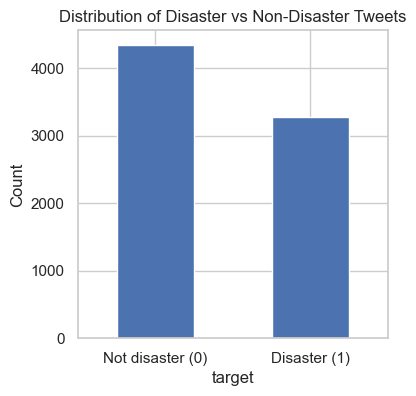

In [16]:
#Reviewing the distribution using a bar chart
plt.figure(figsize=(4,4))
train["target"].value_counts().plot(kind="bar")
plt.xticks([0, 1], ["Not disaster (0)", "Disaster (1)"], rotation=0)
plt.ylabel("Count")
plt.title("Distribution of Disaster vs Non-Disaster Tweets")
plt.show()


In [17]:
#Reviewing missing values
train.isna().sum()


id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

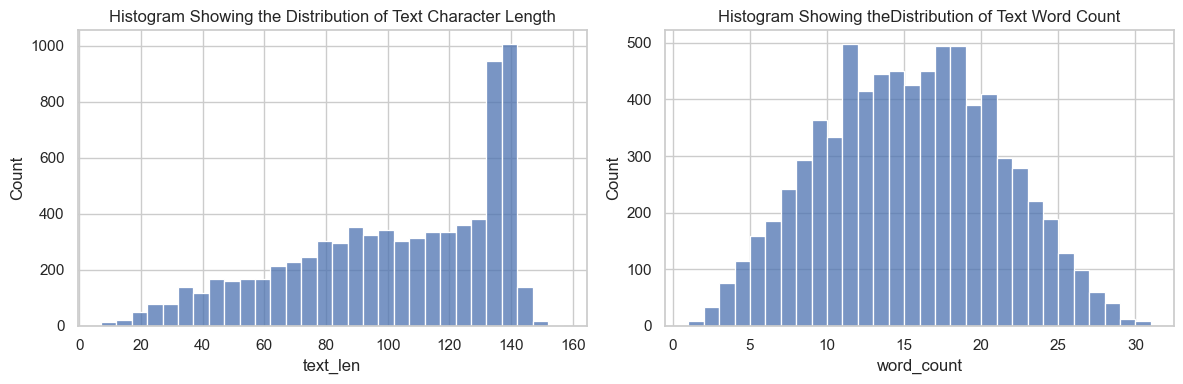

In [18]:
#Reviewing the text length features
train["text_len"] = train["text"].str.len()
train["word_count"] = train["text"].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(train["text_len"], bins=30, ax=axes[0])
axes[0].set_title("Histogram Showing the Distribution of Text Character Length")

sns.histplot(train["word_count"], bins=30, ax=axes[1])
axes[1].set_title("Histogram Showing theDistribution of Text Word Count")

plt.tight_layout()
plt.show()


In [19]:
#Cleaining the tweet text data using regex
import re

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)          
    text = re.sub(r"&\w+;", " ", text)                     
    text = re.sub(r"[^a-z0-9\s]", " ", text)               
    text = re.sub(r"\s+", " ", text).strip()               
    return text

train["text_clean"] = train["text"].apply(clean_text)
test["text_clean"] = test["text"].apply(clean_text)

train[["text", "text_clean"]].head()


,text,text_clean
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",13 000 people receive wildfires evacuation ord...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...


#### Analysis Process

For this analysis I intend to build simple neural model on the tokenized text:

- Evaluate models and perform hyperparameter tuning using a validation split from the training set.

- Select the best model based on F1-score on the validation set and evaluate performance improvement factors. 

#### Modelling Process (Including Architectures)

I'll be using the following neural architectures:

"avg": Embedding → GlobalAveragePooling → Dense

"lstm": Embedding → Bidirectional LSTM → Dense

"cnn": Embedding → Conv1D → GlobalMaxPooling → Dense

In [20]:
#Splitting the data into training and testing sets
RANDOM_STATE = 42

X = train["text_clean"].values
y = train["target"].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

len(X_train), len(X_val)


(6090, 1523)

In [21]:
#Convert text to integer sequences
VOCAB_SIZE = 20000     
MAX_LEN    = 40        

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")

X_train_pad.shape, X_val_pad.shape


((6090, 40), (1523, 40))

In [22]:
from tensorflow.keras import layers, models

def build_model(
    model_type="avg",
    vocab_size=VOCAB_SIZE,
    embed_dim=32,
    max_len=MAX_LEN,
    lstm_units=64,
    num_filters=64,
    kernel_size=3,
    dense_units=32,
    dropout_rate=0.3
):
    model = models.Sequential()
    model.add(layers.Embedding(vocab_size, embed_dim, input_length=max_len))
    
    if model_type == "avg":
        # Model C1: Simple average of embeddings
        model.add(layers.GlobalAveragePooling1D())
        
    elif model_type == "lstm":
        # Model C2: Bidirectional LSTM
        model.add(layers.Bidirectional(layers.LSTM(lstm_units)))
        
    elif model_type == "cnn":
        # Model C3: 1D CNN over embeddings for n-gram patterns
        model.add(layers.Conv1D(num_filters, kernel_size, activation="relu"))
        model.add(layers.GlobalMaxPooling1D())
        
    else:
        raise ValueError("Unknown model_type")
    
    # Shared top layers
    model.add(layers.Dense(dense_units, activation="relu"))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation="sigmoid"))
    
    model.compile(
        loss="binary_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    
    return model


In [23]:
#Running Experiments
EPOCHS = 6
BATCH_SIZE = 64

configs = [
    {"name": "AvgEmbed_small", "type": "avg",  "embed_dim": 32, "dense_units": 32},
    {"name": "AvgEmbed_big",   "type": "avg",  "embed_dim": 64, "dense_units": 64},
    {"name": "BiLSTM_64",      "type": "lstm", "embed_dim": 64, "lstm_units": 64},
    {"name": "CNN_64",         "type": "cnn",  "embed_dim": 64, "num_filters": 64},
]

history_dict = {}
results = []


In [24]:
#Training and evaluating the model

for cfg in configs:
    print(f"\n=== Training {cfg['name']} ({cfg['type']}) ===")
    
    model = build_model(
        model_type   = cfg["type"],
        embed_dim    = cfg.get("embed_dim", 32),
        lstm_units   = cfg.get("lstm_units", 64),
        num_filters  = cfg.get("num_filters", 64),
        dense_units  = cfg.get("dense_units", 32),
        dropout_rate = 0.3
    )
    
    history = model.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )
    
    # Store history for plots later
    history_dict[cfg["name"]] = history
    
    # Evaluate
    y_val_pred_prob = model.predict(X_val_pad).ravel()
    y_val_pred = (y_val_pred_prob >= 0.5).astype(int)
    
    acc = accuracy_score(y_val, y_val_pred)
    f1  = f1_score(y_val, y_val_pred)
    
    print(f"{cfg['name']} -> Val Accuracy: {acc:.4f}, F1: {f1:.4f}")
    
    results.append({
        "Model": cfg["name"],
        "Type": cfg["type"],
        "Val Accuracy": acc,
        "Val F1": f1,
        "Params": cfg
    })



=== Training AvgEmbed_small (avg) ===
Epoch 1/6


c:\Users\godsw\Documents\wk_4\.venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5688 - loss: 0.6809 - val_accuracy: 0.5706 - val_loss: 0.6725
Epoch 2/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6182 - loss: 0.6466 - val_accuracy: 0.6973 - val_loss: 0.6122
Epoch 3/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7783 - loss: 0.5490 - val_accuracy: 0.7708 - val_loss: 0.5223
Epoch 4/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8236 - loss: 0.4533 - val_accuracy: 0.8089 - val_loss: 0.4726
Epoch 5/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8568 - loss: 0.3806 - val_accuracy: 0.8102 - val_loss: 0.4526
Epoch 6/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8785 - loss: 0.3267 - val_accuracy: 0.8181 - val_loss: 0.4408
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
AvgEmbed_small -> Val Accuracy: 0.8181, F1: 0.7678

=== Training AvgEmbed_big (avg) ===
Epoch 1/6


c:\Users\godsw\Documents\wk_4\.venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5713 - loss: 0.6768 - val_accuracy: 0.5726 - val_loss: 0.6578
Epoch 2/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7010 - loss: 0.5951 - val_accuracy: 0.7663 - val_loss: 0.5432
Epoch 3/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8192 - loss: 0.4468 - val_accuracy: 0.7932 - val_loss: 0.4725
Epoch 4/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8677 - loss: 0.3453 - val_accuracy: 0.8142 - val_loss: 0.4412
Epoch 5/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8913 - loss: 0.2813 - val_accuracy: 0.7603 - val_loss: 0.4970
Epoch 6/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9140 - loss: 0.2308 - val_accuracy: 0.8214 - val_loss: 0.4528
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
AvgEmbed_big -> Val Accuracy: 0.8214, F1: 0.7817

=== Training BiLSTM_64 (lstm) ===
Epoch 1/6


c:\Users\godsw\Documents\wk_4\.venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.6739 - loss: 0.6027 - val_accuracy: 0.7938 - val_loss: 0.4547
Epoch 2/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8558 - loss: 0.3505 - val_accuracy: 0.7991 - val_loss: 0.4725
Epoch 3/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9294 - loss: 0.2001 - val_accuracy: 0.7807 - val_loss: 0.5498
Epoch 4/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9576 - loss: 0.1275 - val_accuracy: 0.7426 - val_loss: 0.7703
Epoch 5/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9675 - loss: 0.1002 - val_accuracy: 0.7814 - val_loss: 0.6606
Epoch 6/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9731 - loss: 0.0867 - val_accuracy: 0.7590 - val_loss: 0.7572
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
BiLSTM_64 -> Val Accuracy: 0.7590, F1: 0.7323

=== Training CNN_64 (cnn) ===
Epoch 1/6


c:\Users\godsw\Documents\wk_4\.venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6415 - loss: 0.6378 - val_accuracy: 0.7689 - val_loss: 0.5181
Epoch 2/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8379 - loss: 0.3998 - val_accuracy: 0.8122 - val_loss: 0.4243
Epoch 3/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9202 - loss: 0.2216 - val_accuracy: 0.8050 - val_loss: 0.4786
Epoch 4/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9609 - loss: 0.1254 - val_accuracy: 0.7873 - val_loss: 0.5459
Epoch 5/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9750 - loss: 0.0859 - val_accuracy: 0.7899 - val_loss: 0.5975
Epoch 6/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9780 - loss: 0.0701 - val_accuracy: 0.7768 - val_loss: 0.6522
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
CNN_64 -> Val Accuracy: 0.7768, F1: 0.7436


In [25]:
#Summarizing the model results
results_df = pd.DataFrame(results).sort_values("Val F1", ascending=False)
results_df


,Model,Type,Val Accuracy,Val F1,Params
1,AvgEmbed_big,avg,0.821405,0.781701,"{'name': 'AvgEmbed_big', 'type': 'avg', 'embed..."
0,AvgEmbed_small,avg,0.818122,0.767812,"{'name': 'AvgEmbed_small', 'type': 'avg', 'emb..."
3,CNN_64,cnn,0.776756,0.743590,"{'name': 'CNN_64', 'type': 'cnn', 'embed_dim':..."
2,BiLSTM_64,lstm,0.759028,0.732312,"{'name': 'BiLSTM_64', 'type': 'lstm', 'embed_d..."


#### Analyzing Best Models



In [26]:
best_row = results_df.iloc[0]
best_row

Model                                                AvgEmbed_big
Type                                                          avg
Val Accuracy                                             0.821405
Val F1                                                   0.781701
Params          {'name': 'AvgEmbed_big', 'type': 'avg', 'embed...
Name: 1, dtype: object

In [27]:
def plot_history(history, title_prefix="Model"):
    hist = history.history
    epochs = range(1, len(hist["accuracy"]) + 1)
    
    plt.figure(figsize=(10,4))
    
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, hist["accuracy"], label="Train acc")
    plt.plot(epochs, hist["val_accuracy"], label="Val acc")
    plt.title(f"{title_prefix} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    
    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, hist["loss"], label="Train loss")
    plt.plot(epochs, hist["val_loss"], label="Val loss")
    plt.title(f"{title_prefix} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    
    plt.tight_layout()
    plt.show()


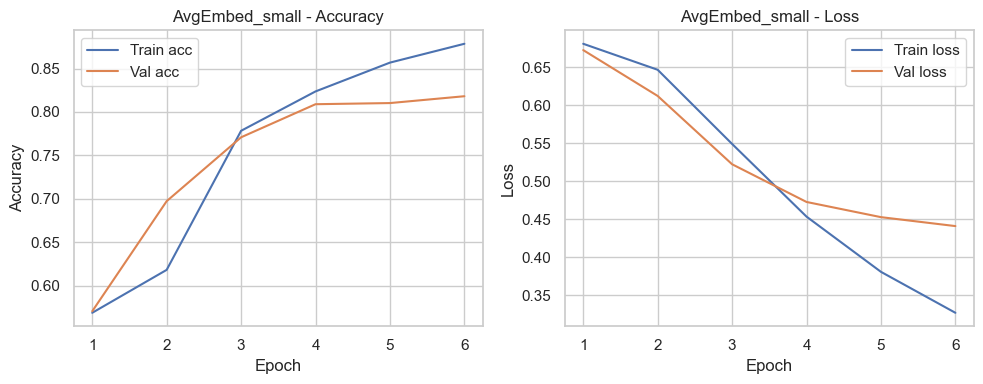

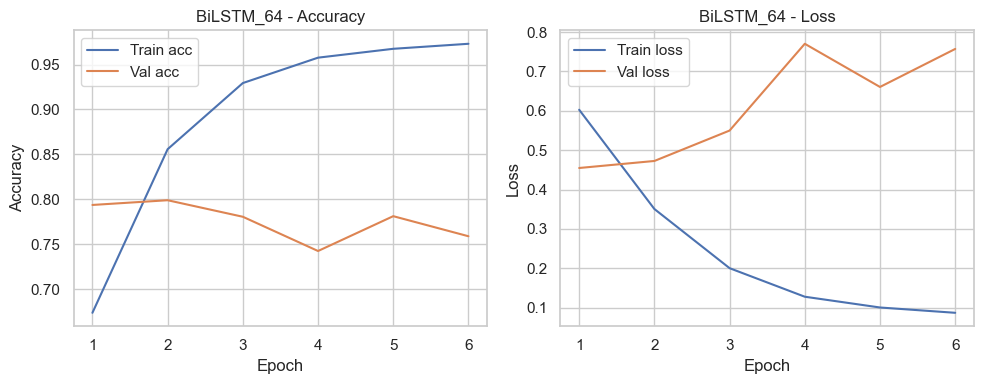

In [28]:
plot_history(history_dict["AvgEmbed_small"], "AvgEmbed_small")
plot_history(history_dict["BiLSTM_64"], "BiLSTM_64")


#Using Confusion Matrix



In [30]:
best_cfg = best_row["Params"]
best_cfg

{'name': 'AvgEmbed_big', 'type': 'avg', 'embed_dim': 64, 'dense_units': 64}

In [31]:
best_model = build_model(
    model_type   = best_cfg["type"],
    embed_dim    = best_cfg.get("embed_dim", 32),
    lstm_units   = best_cfg.get("lstm_units", 64),
    num_filters  = best_cfg.get("num_filters", 64),
    dense_units  = best_cfg.get("dense_units", 32),
    dropout_rate = 0.3
)

history_best = best_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

y_val_pred_prob = best_model.predict(X_val_pad).ravel()
y_val_pred = (y_val_pred_prob >= 0.5).astype(int)

print("Best model classification report:")
print(classification_report(y_val, y_val_pred))


Epoch 1/6


c:\Users\godsw\Documents\wk_4\.venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5714 - loss: 0.6748 - val_accuracy: 0.5765 - val_loss: 0.6526
Epoch 2/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7366 - loss: 0.5772 - val_accuracy: 0.7768 - val_loss: 0.5087
Epoch 3/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8256 - loss: 0.4276 - val_accuracy: 0.7814 - val_loss: 0.4736
Epoch 4/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8660 - loss: 0.3361 - val_accuracy: 0.8181 - val_loss: 0.4346
Epoch 5/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9039 - loss: 0.2591 - val_accuracy: 0.8102 - val_loss: 0.4707
Epoch 6/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9223 - loss: 0.2150 - val_accuracy: 0.8056 - val_loss: 0.4675
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Best model classification report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.83       869
           1       0.77      0.78      0.78       654

    accuracy          

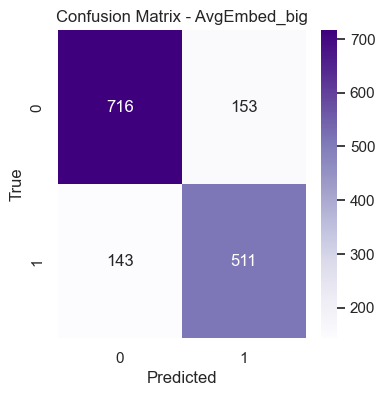

In [32]:
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix - {best_row['Model']}")
plt.show()


#### Results Analysis

I trained 3 neural network architectures with the following results:

In [36]:
results_df

,Model,Type,Val Accuracy,Val F1,Params
1,AvgEmbed_big,avg,0.821405,0.781701,"{'name': 'AvgEmbed_big', 'type': 'avg', 'embed..."
0,AvgEmbed_small,avg,0.818122,0.767812,"{'name': 'AvgEmbed_small', 'type': 'avg', 'emb..."
3,CNN_64,cnn,0.776756,0.743590,"{'name': 'CNN_64', 'type': 'cnn', 'embed_dim':..."
2,BiLSTM_64,lstm,0.759028,0.732312,"{'name': 'BiLSTM_64', 'type': 'lstm', 'embed_d..."


- AvgEmbed models performed with the best accuracy and speed
- CNN models performed lower the AvgEmded but obtained an Accuracy and F1 score better than BiLSTM
- BiLSTM had the least performance

#### Conclusion

The results show that, for this dataset, simple embedding + average pooling architectures outperform more complex sequence models (CNN and BiLSTM). This demonstrates that lightweight semantic features can be more efective in classification. 

Main highlights:

AvgEmbed models are better performers for short, noisy text like tweets.

Complex models (CNN, BiLSTM) may have been impacted by limited dataset size and minimal sequence structure.


Future improvements could include utilizing keyword/location features, or fine-tuning a transformer model. 

#### Kaggle Submission

In [33]:
# Prepare test sequences
X_test_text = test["text_clean"].values
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)
X_test_pad  = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

test_pred_prob = best_model.predict(X_test_pad).ravel()
test_pred = (test_pred_prob >= 0.5).astype(int)

submission = pd.DataFrame({
    "id": test["id"],
    "target": test_pred
})

submission.head()


102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


In [35]:
submission.to_csv("submission_for_kaggle.csv", index=False)
